In [323]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, rotator
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

import glob
import os


In [324]:
df=pd.read_excel(r'C:\Users\johan\Documents\Documents\School\EDA_course\lab1\stockreturns.xlsx',header=None)

df

,0,1,2,3,4,5,6,7,8,9
0,0.447813,0.067331,0.150311,2.991352,-0.207695,0.455964,-0.781059,0.205240,-0.001368,1.464562
1,0.988109,1.581645,-0.611253,2.620408,0.535787,0.589932,1.207660,1.065817,-0.551631,0.202665
2,0.874563,0.756208,-2.180025,-0.362371,1.371877,0.918730,1.114681,1.544983,1.523075,0.347807
3,0.714403,-0.689844,0.253764,2.209370,0.580143,1.837029,0.919674,0.422198,-0.417153,-1.009343
4,0.005351,-1.342888,-2.064859,-2.407927,-0.186868,-0.172721,0.154608,-1.103909,0.203125,1.997488
...,...,...,...,...,...,...,...,...,...,...
95,-1.202835,-0.475408,0.878834,-5.016160,-1.827819,-1.073763,0.045913,0.821147,0.995893,-1.238048
96,0.033411,-0.294351,-3.466637,0.385052,0.175829,-0.500618,-2.314474,0.121723,-1.052358,-0.665537
97,1.104768,2.051862,0.926894,0.533393,-0.694438,-1.091278,-4.363289,1.244669,1.244691,0.273739
98,2.228001,1.716761,1.629434,1.438094,1.167099,0.200579,1.614918,-0.426848,-0.029258,-2.649804


In [325]:
column_names=[1,2,3,4,5,6,7,8,9,10]
df.columns=column_names
print(df.describe())
print(df.info())
print(df.isna().sum())

#center data and standarizr to scale to unit variance
Z=StandardScaler(with_mean=True,with_std=True).fit_transform(df)

R=np.corrcoef(Z,rowvar=False)


               1           2           3           4           5           6   \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    -0.205973   -0.185383   -0.417730   -0.000587   -0.041528   -0.079531   
std      1.042490    1.266151    1.602665    2.359008    0.997932    1.327798   
min     -3.496073   -2.561813   -4.438418   -5.876362   -2.567118   -3.419913   
25%     -0.787180   -1.092094   -1.774183   -1.498274   -0.686821   -0.967786   
50%     -0.198705   -0.284070   -0.388363    0.061700    0.076987   -0.066803   
75%      0.409016    0.701761    0.821638    1.680436    0.564746    0.980467   
max      2.228001    3.180881    2.925340    6.469176    2.073680    2.741017   

               7           8           9           10  
count  100.000000  100.000000  100.000000  100.000000  
mean     0.166941   -0.139690   -0.108592    0.030517  
std      1.708513    1.084282    1.333681    1.497075  
min     -4.650008   -2.496761   -3.986496   -3

### scree plot for picking m

[3.02286632 2.20308075 1.35438718 0.85930551 0.68266141 0.6194473
 0.49103372 0.33732547 0.24042265 0.1894697 ]


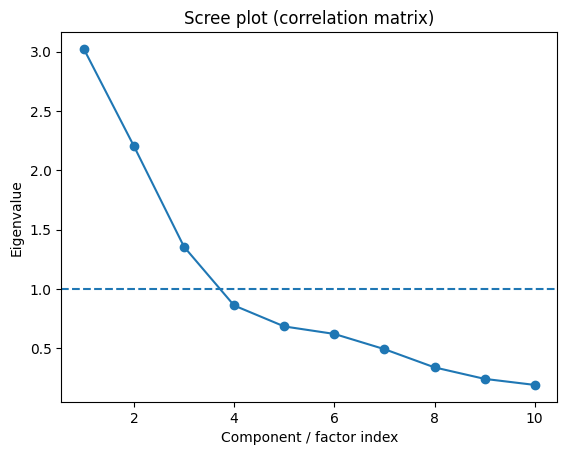

In [326]:

eigvals=np.linalg.eigvalsh(R) # extract eigenvals
eigvals=eigvals[::-1] # reverse order to descending
print(eigvals)
plt.plot(range(1,len(eigvals)+1),eigvals, marker='o')
plt.axhline(1.0, linestyle='--') # Kaiser line
plt.xlabel("Component / factor index")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (correlation matrix)")
plt.show()

In [327]:
def plot(scores,title=None):
    pairs = [(0,1), (0,2), (1,2)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)
    titles = ["F1 vs F2", "F1 vs F3", "F2 vs F3"]
    for ax, (a, b), t in zip(axes, pairs, titles):
        ax.scatter(scores[:, a], scores[:, b], s=12, alpha=0.7)
        ax.axhline(0)
        ax.axvline(0)
        ax.set_xlabel(f"Factor {a+1} score")
        ax.set_ylabel(f"Factor {b+1} score")
        ax.set_title(t+f"({title})")
        
    plt.tight_layout()
    plt.show()
        


In [328]:
def factor_analysis(matr,rotation='varimax',m=0, method='minres',svd_method='lapack'):
    fa_ = FactorAnalyzer(n_factors=m, rotation= rotation, method=method,svd_method=svd_method)
    fa_.fit(matr)
    scores=fa_.transform(matr)
    loadings=fa_.loadings_
    print(loadings)
    plot_loadings(loadings,[0,1,2,3,4,5,6,7,8,9],rotation)

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


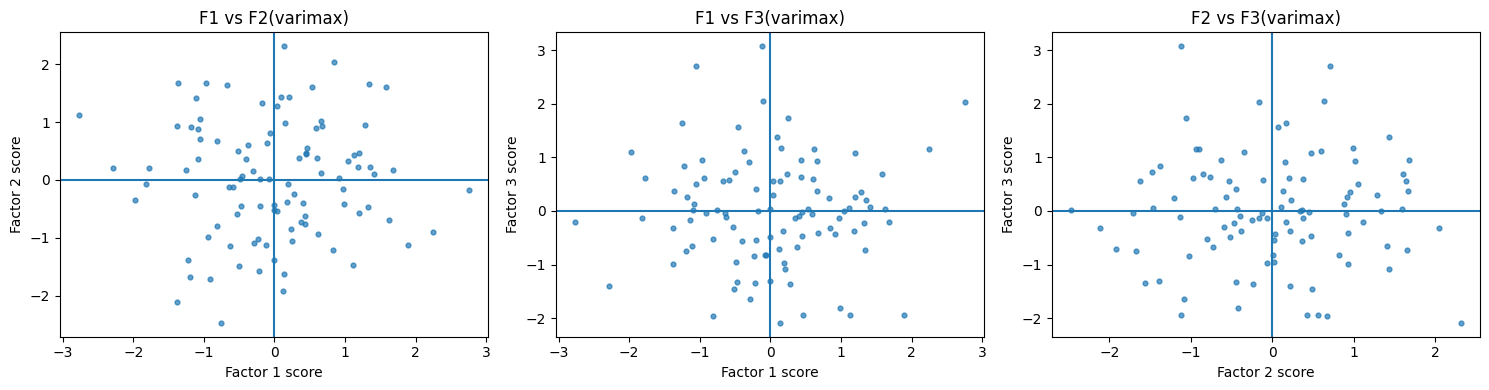

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


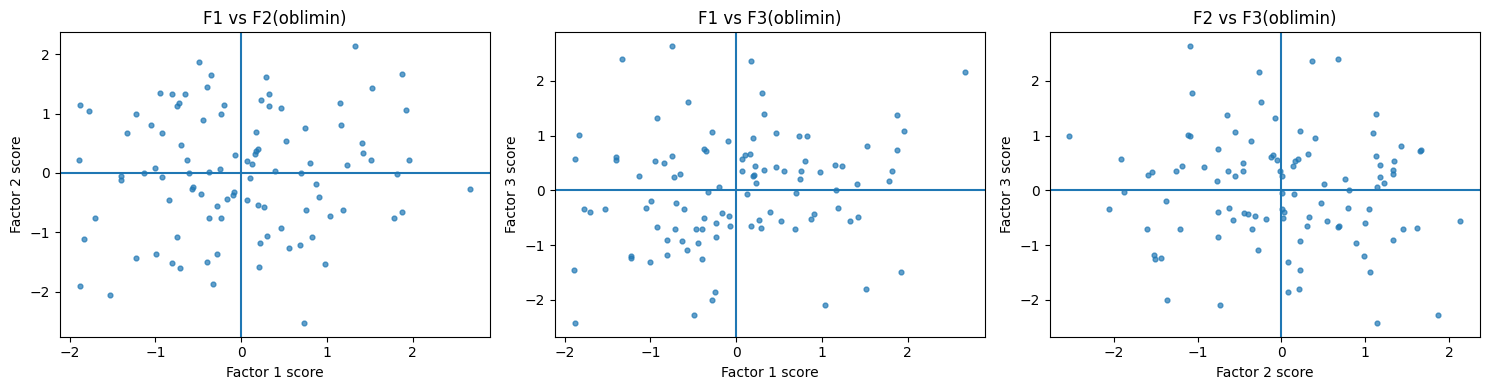

In [329]:

m=3 

fa_varimax = FactorAnalyzer(n_factors=m, rotation= 'varimax', method='principal',svd_method='lapack')
fa_varimax.fit(Z)
scores_varimax=fa_varimax.transform(Z)

plot(scores_varimax,'varimax')


fa_Promax = FactorAnalyzer(n_factors=m, rotation= 'oblimin', method='principal',svd_method='lapack')
fa_Promax.fit(Z)
scores_quartimax=fa_Promax.transform(Z)
plot(scores_quartimax,'oblimin')


In [330]:
def plot_loadings(loadings, feature_names=None, rotation=None):
    titles=["Loadings: F1 vs F2", "Loadings: F1 vs F3", "Loadings: F2 vs F3"]
    pairs=[(0,1),(0,2),(1,2)]# list of tuples f1,f2 f1,f3 & f2,f3
    fig, axis=plt.subplots( 1 , 3 , figsize=(15, 4))

    for t, (a, b), ax in zip(titles, pairs,axis):
        ax.scatter(loadings[:,a],loadings[:,b],c='red' )
        ax.axhline(0)
        ax.axvline(0)
        ax.legend(t)
        ax.set_xlabel(f"Factor{a+1} loading")
        ax.set_ylabel(f"Factor{b+1} loading")
        ax.set_title(rotation)
        for i, name in enumerate(feature_names):
            ax.text(loadings[i, a], loadings[i, b], name, fontsize=11)
    
    plt.show()    
    

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[ 1.00000000e+00  8.11462691e-02  1.71527039e-01  3.68559205e-01
   3.13590803e-01 -1.55945984e-01  4.02763583e-01  4.73779744e-01
   2.07539699e-01  7.22793755e-01]
 [ 8.11462691e-02  1.00000000e+00 -7.71475355e-02 -2.80593940e-02
   1.05391314e-01  3.73051871e-01 -2.24659014e-01  2.26698072e-01
   7.22700583e-01  2.63034232e-01]
 [ 1.71527039e-01 -7.71475355e-02  1.00000000e+00  7.89266031e-02
  -5.61202607e-02 -9.32122538e-02  3.91180497e-01  4.03175342e-01
   4.69729506e-02 -6.62754983e-04]
 [ 3.68559205e-01 -2.80593940e-02  7.89266031e-02  1.00000000e+00
   1.20823649e-01 -9.79169202e-02  2.47944049e-01  1.98909128e-01
   3.36759924e-02  3.68429611e-01]
 [ 3.13590803e-01  1.05391314e-01 -5.61202607e-02  1.20823649e-01
   1.00000000e+00 -7.51942197e-02  8.44029988e-03  1.23658760e-01
   8.71376444e-02  3.33657538e-01]
 [-1.55945984e-01  3.73051871e-01 -9.32122538e-02 -9.79169202e-02
  -7.51942197e-02  1.00000000e+00 -2.03973327e-01 -2.91515709e-02
 

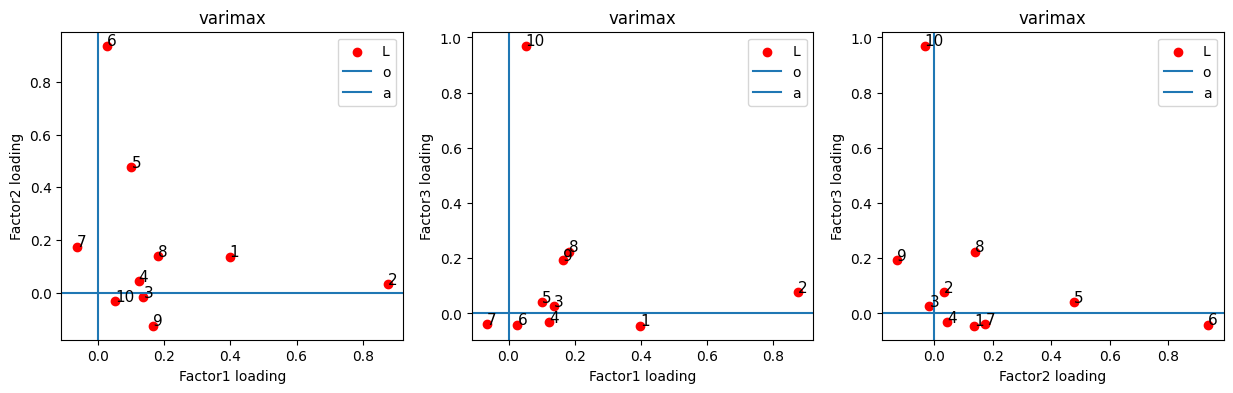

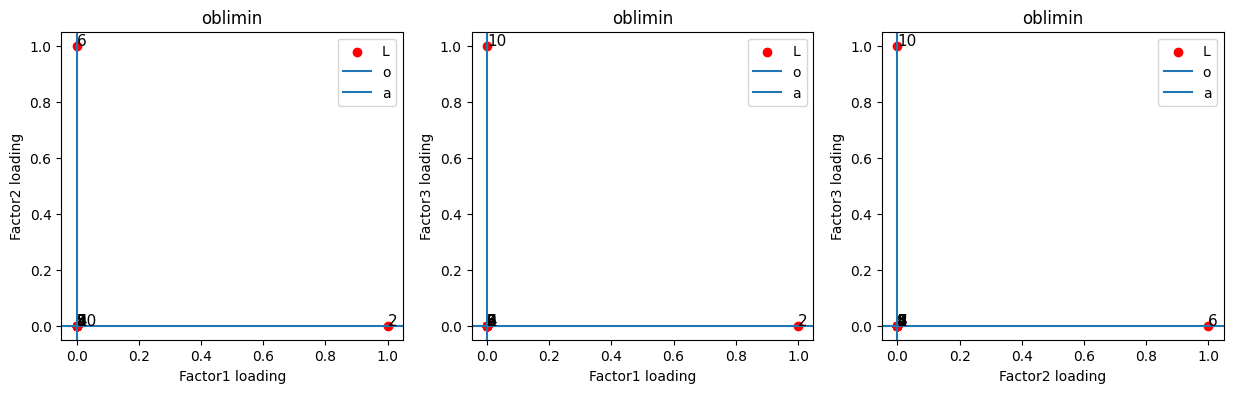

In [331]:
loadings_v=fa_varimax.loadings_
uniqueness_v=fa_varimax.get_uniquenesses()
communalities_v=fa_varimax.get_communalities()
tuple_v=fa_varimax.get_factor_variance()
loadings_pro=fa_Promax.loadings_
print(communalities_v)
print(fa_Promax.phi_)
loadings_v.shape #(10,3)
uniqueness_v.shape #(10,)
communalities_v.shape#(10,)
names=df.columns.to_list()
print(names)
plot_loadings(loadings_v,names,'varimax')
plot_loadings(loadings_pro,names,'oblimin')

(100, 10)


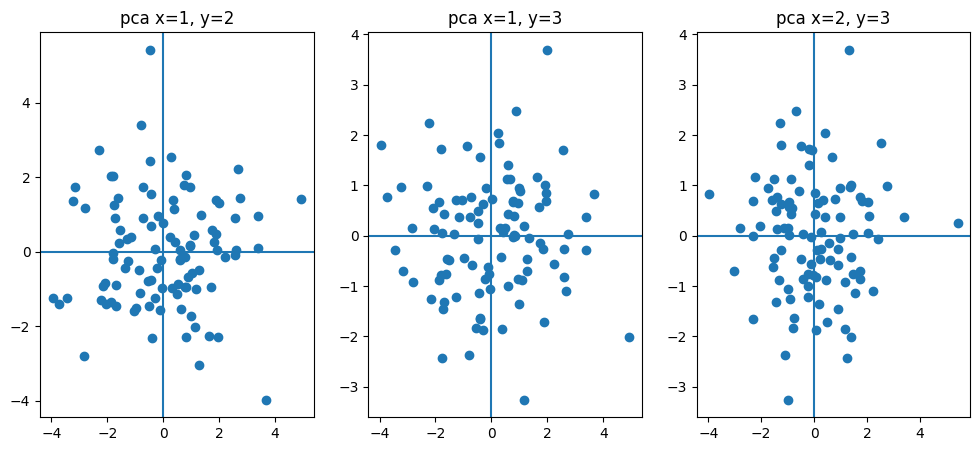

In [332]:
eigval,eigvec=np.linalg.eigh(R)
eigval=eigval[::-1]
eigvec = eigvec[:, ::-1]
PC_1_3=eigvec[:,:3]
T1=Z @ eigvec
print(T1.shape)
fig, axis=plt.subplots(1,3,  figsize=(12, 5))
pairs=[(0,1),(0,2),(1,2)]
for ax,(a,b) in zip(axis, pairs):
    ax.scatter(T1[:,a],T1[:,b])
    ax.axhline(y=0)
    ax.axvline(x=0)
    ax.set_title(f"pca x={a+1}, y={b+1}")

###Q1-c


In [333]:
path1=r'C:\Users\johan\Documents\Documents\School\EDA_course\lab1\sw_stock_idx'
all_files = glob.glob(os.path.join(path1 , "*.csv"))# glob return list of paths, os.path.join find all files with csv extentions 
comp=['abb','atcoa','jm','ncca','ndadk','saabb','seba','shba','skab','volva']

li=[]
for file in all_files:
    df=pd.read_csv(file,sep=';', skiprows=1, usecols=[6]) #need semicolumn to seperate colomns, ship first row use column 6
    li.append(df)

frame = pd.concat(li, axis=1)
frame=frame.drop(axis=0, index=[20,21])

frame.columns=comp
frame=frame.pct_change().mul(100).fillna(0)
frame


,abb,atcoa,jm,ncca,ndadk,saabb,seba,shba,skab,volva
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-1.108247,0.160471,-0.444444,0.000000,-0.991277,2.453081,-0.507228,-0.244158,-0.973324,-3.106682
2,-0.416992,-1.869159,1.636905,-1.709402,-2.482980,0.721189,-2.447107,-1.678322,-1.383327,-1.996370
3,-7.720492,-0.136054,2.489019,0.434783,-0.451745,1.145639,-1.228116,0.106686,-0.738280,-0.308642
4,0.311968,-0.844687,1.071429,0.000000,3.135314,1.231771,7.248677,1.136767,-0.520640,0.247678
5,-2.092169,2.555647,-1.272085,-0.865801,1.440000,-1.958042,0.641342,0.456621,0.523364,-2.655960
6,-1.530465,1.982851,0.071582,0.000000,-1.222397,2.539230,-1.323529,-1.188811,-0.297508,0.253807
7,-0.557185,-0.367840,2.217454,-1.310044,-0.598802,-3.797997,-0.447094,-0.955414,0.708691,-0.189873
8,0.707756,0.474684,1.329601,-0.884956,1.726908,4.497469,1.097804,1.071811,0.629630,0.253646
9,1.346999,-0.446194,-1.312155,-2.232143,-2.487169,0.996402,-1.579467,-1.343231,-2.097902,-1.454775


[3.72485733 1.84845561 1.24166178 0.85953754 0.70568688 0.55820096
 0.47058666 0.34370474 0.19472561 0.0525829 ]


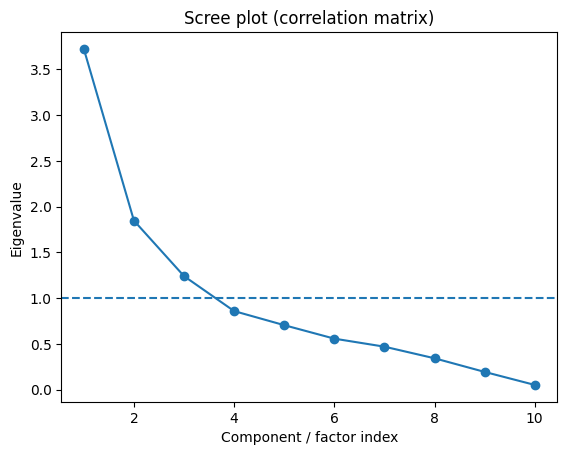

In [334]:

frame_z=StandardScaler(with_mean=True,with_std=True).fit_transform(frame)# standarize with centering and using unit variance

frame_r=np.corrcoef(frame_z,rowvar=False)


eigvals_C=np.linalg.eigvalsh(frame_r) # extract eigenvals
eigvals_C=eigvals_C[::-1] # reverse order to descending
print(eigvals_C)
plt.plot(range(1,len(eigvals_C)+1),eigvals_C, marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel("Component / factor index")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (correlation matrix)")
plt.show()

[[ 4.66538693e-02 -2.86568169e-02  9.77728327e-01 -1.03065261e-01
  -1.49057224e-02 -1.97364062e-02 -1.50670561e-01  6.70331887e-02
  -4.41043138e-03 -5.09985192e-02]
 [ 8.37811748e-02  8.22854509e-03 -1.27526666e-01  9.21776484e-01
   7.44683057e-02  1.82965967e-01  1.49714653e-01  2.54529298e-01
   4.43708834e-03 -2.71416079e-02]
 [ 5.54322381e-02  2.26686164e-02 -1.82628605e-01  1.53285071e-01
   1.64510222e-01  1.92325017e-01  9.18725469e-01  1.56919289e-01
  -4.63081245e-04 -8.26498040e-02]
 [ 1.84630357e-01  8.07100638e-02 -2.29215943e-02  2.04675678e-01
   1.60555903e-01  8.93710879e-01  2.09997642e-01  1.49761283e-01
   2.14285314e-03 -1.61091922e-01]
 [ 9.12302108e-01  1.47885154e-01 -3.80484803e-02  1.32570817e-01
   1.77938112e-01  8.90957542e-02  1.52699473e-02  2.12921984e-01
   2.01473261e-01 -3.24298404e-02]
 [ 6.71120290e-02  3.06540856e-02 -4.97172159e-02 -2.57129742e-02
  -7.12596527e-02 -1.20054293e-01 -6.95579812e-02 -6.18974222e-02
  -2.60141499e-03  9.81456062e-01

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


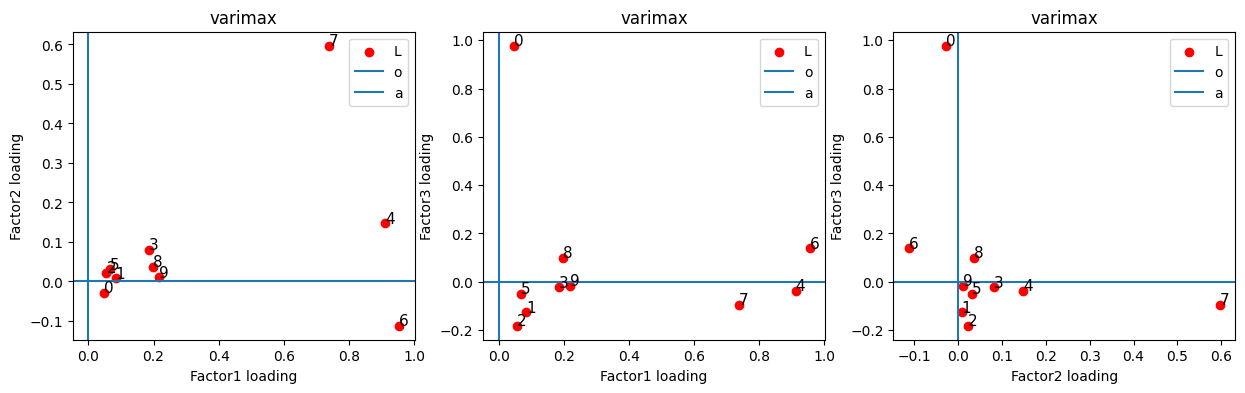

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[[-0.09443374  0.34374964  0.82419288  0.27051716  0.0684505   0.28896936
  -0.05113588  0.09328397  0.14304329  0.02186527]
 [ 0.58064685 -0.44788002 -0.14751566  0.51130758 -0.13699938 -0.22054864
   0.11666408  0.27679008  0.14542923 -0.01652161]
 [ 0.55399594 -0.52692886 -0.22593367 -0.1742134   0.1675678   0.31192533
  -0.43919991  0.09809621  0.07480509  0.02337802]
 [ 0.70367114 -0.3177864   0.09088789 -0.11631485 -0.27281709  0.39948759
   0.34975468  0.04203069 -0.15231992  0.02744459]
 [ 0.83182548  0.46903277 -0.01718552 -0.04477655 -0.0746748  -0.21023168
  -0.06460246 -0.02329979  0.00175498  0.17686498]
 [-0.15294067  0.47203788 -0.58169111  0.44632327  0.33655053  0.29770231
   0.10710284  0.00357263 -0.04563306  0.02759174]
 [ 0.66726873  0.62396221  0.06459873 -0.0874711   0.03253658 -0.06437364
  -0.14378104  0.28835922 -0.18688521 -0.09821768]
 [ 0.71822187  0.48110546 -0.2317466  -0.10145947 -0.24834484  0.11990456
   0.03403135 -0.21852484  0.23786273 -0.08457066]


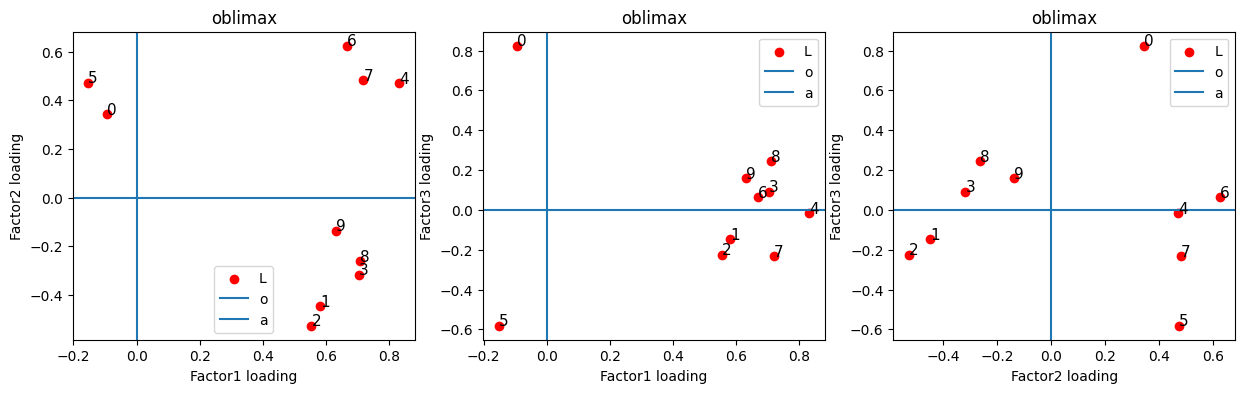

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[[ 5.82328851e-06 -4.09270338e-06  9.99727192e-01 -1.55455127e-04
  -6.45137570e-08 -2.36924378e-07 -7.21573087e-04  3.53484918e-05
  -8.49753415e-08 -7.28949823e-06]
 [ 6.05624478e-05  2.78221501e-08 -2.89342840e-04  9.94622595e-01
   4.01907496e-05  1.74992211e-03  7.03434945e-04  7.34788735e-03
   8.70484296e-08 -5.84803094e-07]
 [ 1.16055918e-05  1.60250180e-06 -1.21698135e-03  7.60598135e-04
   9.57220012e-04  2.13639015e-03  9.97492710e-01  1.06149193e-03
  -1.03275456e-11 -5.02845633e-05]
 [ 1.42833498e-03  2.57518978e-04 -3.01986827e-07  2.41780225e-03
   8.68451012e-04  9.96152043e-01  2.72285417e-03  8.80662659e-04
   4.73519945e-09 -7.25708857e-04]
 [ 8.51475877e-01  2.90266412e-03 -2.29275671e-06  4.25547018e-04
   1.31013525e-03  9.83932906e-05  7.61231692e-08  3.59826703e-03
   3.70031163e-01 -1.19191864e-06]
 [ 2.49355592e-05  5.35860740e-06 -6.68399191e-06 -6.02233740e-07
  -3.36988453e-05 -3.24375642e-04 -3.27758967e-05 -2.56981360e-05
  -1.02850687e-08  9.99886759e-01

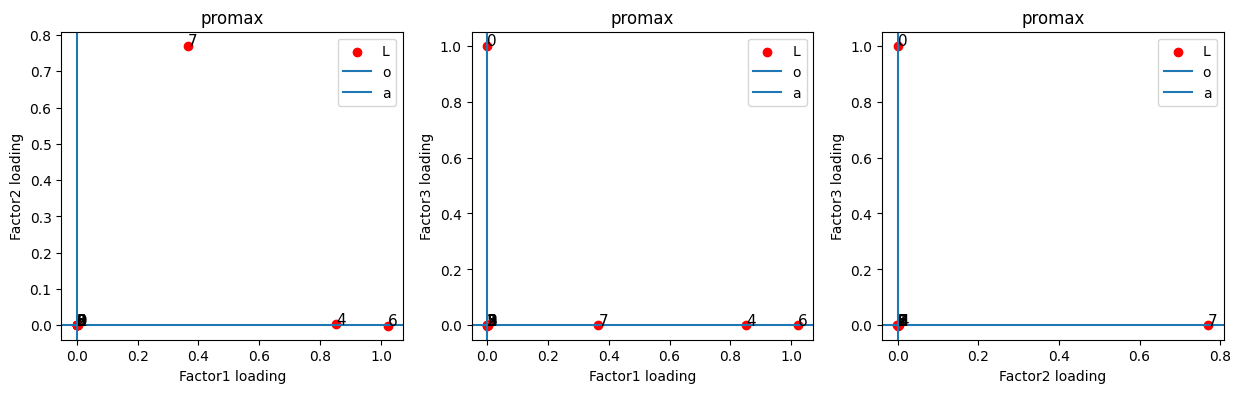

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[[ 3.13997967e-02 -5.10493493e-02  9.79133612e-01 -1.02698601e-01
  -1.36084838e-02 -1.86122871e-02 -1.49343617e-01  6.47135422e-02
  -1.16286510e-02  4.37301442e-04]
 [ 1.26530997e-01 -3.03867675e-02 -1.25959973e-01  9.27735375e-01
   6.96887657e-02  1.70220412e-01  1.48808479e-01  2.24791951e-01
  -7.69370767e-04 -4.70924456e-04]
 [ 9.60064018e-02 -8.54120923e-02 -1.83471067e-01  1.59204439e-01
   1.59492141e-01  1.82933429e-01  9.19420175e-01  1.42190772e-01
   5.07441767e-03  2.31291067e-04]
 [ 2.59408302e-01 -1.68309949e-01 -2.42516803e-02  2.10515733e-01
   1.49515762e-01  8.80322645e-01  2.12162589e-01  1.29085325e-01
   2.17868331e-02 -7.09220429e-04]
 [ 9.48741656e-01 -4.61981186e-02 -3.16922272e-02  1.21773015e-01
   1.44391764e-01  3.76783125e-02  4.56724244e-03  1.63957496e-01
   6.87304636e-04 -1.80969365e-01]
 [ 7.04595428e-02  9.81588269e-01 -5.01075448e-02 -2.98628896e-02
  -7.30795578e-02 -1.18631947e-01 -7.13411180e-02 -5.94426707e-02
   8.94211797e-03  5.07165687e-04

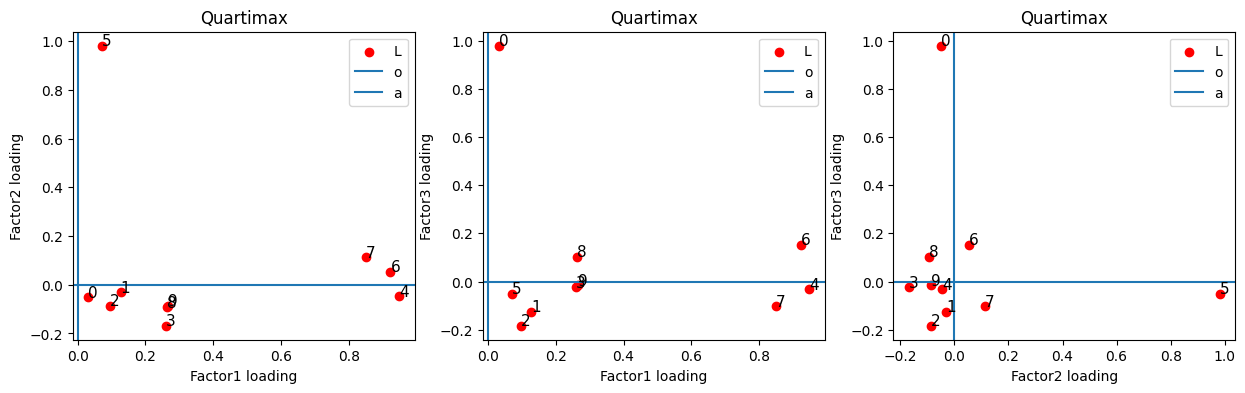

In [335]:
factor_analysis(rotation='varimax' , m=3 , method='principal' , svd_method='lapack',matr=frame_z)
factor_analysis(rotation='oblimax' , m=3 , method='principal' , svd_method='lapack',matr=frame_z)
factor_analysis(rotation='promax' , m=3 , method='principal' , svd_method='lapack',matr=frame_z)
factor_analysis(rotation='Quartimax' , m=3 , method='principal' , svd_method='lapack',matr=frame_z)


